# Phase 5 — SHAP Interpretability: RB

Explains `rb_model.json`'s predictions using SHAP (SHapley Additive exPlanations) on the same training set used to build it, with the same 4 locked features (`config/selected_features.yaml`): `scarcity_z`, `vorp_delta_yoy`, `age`, `draft_pick_inverse`. Same structure and same standard as `08a_shap_qb.ipynb`, so findings can be compared directly across positions rather than read in isolation.

Four things are covered: a global feature-importance view (beeswarm + comparison against gain importance), local explanations for the five RBs already investigated in `06b_model_rb.ipynb`'s live 2026 prediction (with extra attention on De'Von Achane specifically, whose predicted decline is proportionally steep despite a delta well inside the normal range), a reusable `explain_player` function, and replication checks against QB's two open SHAP mysteries (`vorp_delta_yoy`'s extreme-tail saturation, and `scarcity_z`'s top-decile difficulty).

## Setup

`shap.TreeExplainer` computes exact Shapley values for tree ensembles in polynomial time by exploiting the tree structure directly, rather than the model-agnostic sampling `KernelExplainer` would require. Applied here to `rb_model.json` and the identical feature matrix `06b_model_rb.ipynb` trained on. RB's model is fit with monotonic constraints on `scarcity_z` and `vorp_delta_yoy` (— the opposite tuning call from QB's unconstrained model — which does not change how `TreeExplainer` works, but is worth keeping in mind when comparing the two positions' dependence plots below: a constrained feature's SHAP curve is guaranteed monotonic by construction, not just observed to be.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nflreadpy as nfl
import numpy as np
import pandas as pd
import shap
import xgboost as xgb

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FEATURES = ["scarcity_z", "vorp_delta_yoy", "age", "draft_pick_inverse"]

vorp_labels = pd.read_parquet(REPO_ROOT / "data/processed/vorp_labels.parquet")
rb = vorp_labels[vorp_labels["position"] == "RB"][
    ["season", "player_id", "player_display_name", "vorp", "vorp_next"]
].copy()

season_position_stats = (
    vorp_labels.groupby(["season", "position"])["vorp"]
    .agg(position_mean_vorp="mean", position_std_vorp_that_season="std")
    .reset_index()
)
rb_stats = season_position_stats[season_position_stats["position"] == "RB"]
rb = rb.merge(rb_stats[["season", "position_mean_vorp", "position_std_vorp_that_season"]], on="season", how="left")
rb["scarcity_z"] = (rb["vorp"] - rb["position_mean_vorp"]) / rb["position_std_vorp_that_season"]
rb = rb.drop(columns=["position_mean_vorp", "position_std_vorp_that_season"])

prior = rb[["player_id", "season", "vorp"]].copy()
prior["season"] = prior["season"] + 1
prior = prior.rename(columns={"vorp": "vorp_last_season"})
rb = rb.merge(prior, on=["player_id", "season"], how="left")
rb["vorp_delta_yoy"] = rb["vorp"] - rb["vorp_last_season"]
rb = rb.drop(columns=["vorp_last_season"])

players = nfl.load_players().to_pandas()
rb = rb.merge(players[["gsis_id", "birth_date", "draft_pick"]], left_on="player_id", right_on="gsis_id", how="left")
rb["birth_date"] = pd.to_datetime(rb["birth_date"])
season_start = pd.to_datetime(rb["season"].astype(str) + "-09-01")
rb["age"] = (season_start - rb["birth_date"]).dt.days / 365.25
rb["draft_pick_inverse"] = 1 / rb["draft_pick"]
rb = rb.drop(columns=["gsis_id", "birth_date", "draft_pick"])

rb_2025_features = rb[rb["season"] == 2025].copy()
rb = rb.dropna(subset=["vorp_next"]).reset_index(drop=True)
print(f"RB training rows: {len(rb)}")

model = xgb.XGBRegressor()
model.load_model(str(REPO_ROOT / "data" / "models" / "rb_model.json"))

explainer = shap.TreeExplainer(model)
shap_values = explainer(rb[FEATURES])
print(f"SHAP values computed: {shap_values.values.shape}")
print(f"Base value (expected model output over the training set): {explainer.expected_value:.3f}")


C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RB training rows: 1823
SHAP values computed: (1823, 4)
Base value (expected model output over the training set): -44.693


## Global summary

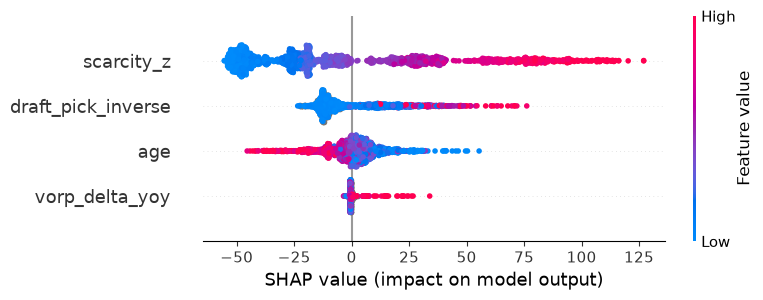

In [2]:
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()


**Figure 1.** SHAP beeswarm plot, all RB training rows. Each point is one player-season; horizontal position is that row's SHAP contribution to the predicted VORP; color is the underlying feature value (red = high, blue = low).

In [3]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_rank = pd.DataFrame({"feature": FEATURES, "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_rank["shap_rank"] = shap_rank.index + 1

gain_scores = model.get_booster().get_score(importance_type="gain")
gain_df = pd.DataFrame({"feature": list(gain_scores.keys()), "gain": list(gain_scores.values())})
missing = [f for f in FEATURES if f not in gain_df["feature"].values]
if missing:
    gain_df = pd.concat([gain_df, pd.DataFrame({"feature": missing, "gain": 0.0})], ignore_index=True)
gain_df["gain_share"] = gain_df["gain"] / gain_df["gain"].sum()
gain_df = gain_df.sort_values("gain_share", ascending=False).reset_index(drop=True)
gain_df["gain_rank"] = gain_df.index + 1

comparison = shap_rank.merge(gain_df[["feature", "gain_share", "gain_rank"]], on="feature")
comparison = comparison.sort_values("shap_rank")[["feature", "shap_rank", "mean_abs_shap", "gain_rank", "gain_share"]]
print(comparison.to_string(index=False))


           feature  shap_rank  mean_abs_shap  gain_rank  gain_share
        scarcity_z          1      38.331421          1    0.750641
draft_pick_inverse          2      13.770601          2    0.103594
               age          3       8.353029          3    0.085862
    vorp_delta_yoy          4       0.916186          4    0.059904


**Table 1.** SHAP global ranking (mean absolute SHAP value across all RB training rows) against gain-importance ranking (final shipped model).

**Full agreement, not just at the top and bottom.** RB's SHAP ranking and gain-importance ranking are **identical at all four ranks**: `scarcity_z` (1st, both measures), `draft_pick_inverse` (2nd, both), `age` (3rd, both), `vorp_delta_yoy` (4th, both). This is a real contrast with QB, where the two measures agreed on `scarcity_z` (dominant) and `ol_pass_protection_proxy` (weakest) but disagreed in the middle — gain ranked `passing_epa` above `draft_pick_inverse` while SHAP ranked them the other way. RB shows no such disagreement anywhere in its (much shorter) ranking.

**A second, more striking finding sits underneath the ranking, though**: `vorp_delta_yoy`'s mean absolute SHAP value (0.92) is tiny next to `scarcity_z`'s (38.33) — `scarcity_z` alone accounts for roughly 75% of gain share, matching `06b_model_rb.ipynb`'s own reported figure. For QB, `vorp_delta_yoy` was a genuinely influential secondary feature (its extreme-tail contribution was the largest driver behind Lawrence's, Maye's, and Stafford's flagged 2026 predictions). For RB, on this evidence, it barely moves most predictions at all — a real, position-specific difference in how much the model leans on this feature, worth carrying into Mystery 1 below rather than assuming RB's `vorp_delta_yoy` behaves like QB's just because it has the same name.

## Local explanations: the five RBs from the live 2026 prediction

The same five rows evaluated in `06b_model_rb.ipynb`'s live 2026 prediction section — each RB's real, already-realized 2025 season, feeding a prediction of 2026 VORP: Christian McCaffrey and Jonathan Taylor (both flagged `low_confidence_extreme_delta`, `|vorp_delta_yoy| > 100`), and Bijan Robinson, Jahmyr Gibbs, and De'Von Achane (all unflagged, moderate deltas).

**De'Von Achane gets specific extra attention here.** His delta (48.97) sits comfortably inside the normal range — nowhere near the 100 threshold — yet his predicted 2026 VORP (+44.7) is a steep, proportionally large decline from his realized 2025 VORP (+163.9), roughly the same size of drop as McCaffrey's and Taylor's flagged, extreme-delta predictions. A prediction that steep without an extreme-delta trigger is exactly the kind of case worth checking against SHAP directly, rather than trusting the flag alone: if the flag is silent, something else in his feature row must be doing the work, and this section asks what.

=== Christian McCaffrey ===
Predicted 2026 VORP: 74.667   (base -44.693 + sum(SHAP) = 74.667)
           feature   value       shap
        scarcity_z   3.396  98.481003
               age  29.235 -36.512001
draft_pick_inverse   0.125  34.583000
    vorp_delta_yoy 345.870  22.808001


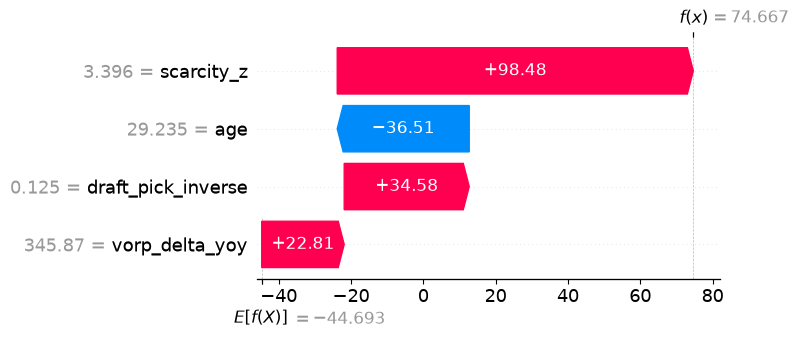


=== Jonathan Taylor ===
Predicted 2026 VORP: 77.568   (base -44.693 + sum(SHAP) = 77.568)
           feature   value       shap
        scarcity_z   3.092 106.338997
draft_pick_inverse   0.024  19.504000
               age  26.617  -5.369000
    vorp_delta_yoy 124.170   1.786000


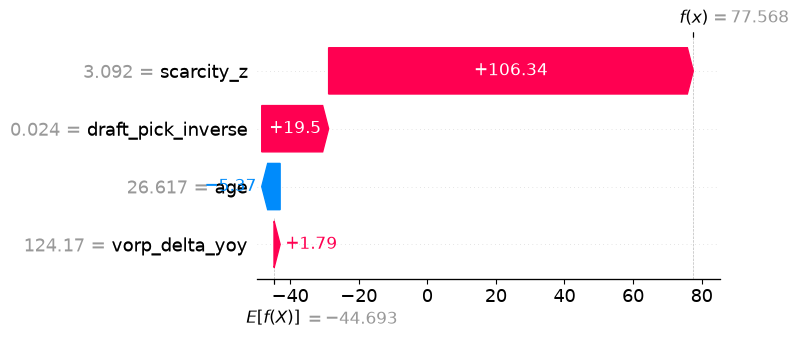


=== Bijan Robinson ===
Predicted 2026 VORP: 131.107   (base -44.693 + sum(SHAP) = 131.107)
           feature  value      shap
        scarcity_z  3.000 99.773003
draft_pick_inverse  0.125 60.020000
               age 23.587 17.450001
    vorp_delta_yoy 40.670 -1.442000


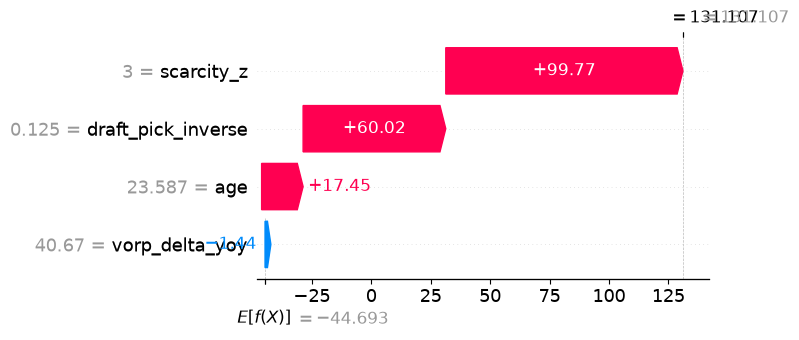


=== Jahmyr Gibbs ===
Predicted 2026 VORP: 102.302   (base -44.693 + sum(SHAP) = 102.302)
           feature  value       shap
        scarcity_z  2.967 101.424004
draft_pick_inverse  0.083  34.970001
               age 23.452  13.431000
    vorp_delta_yoy 12.070  -2.831000


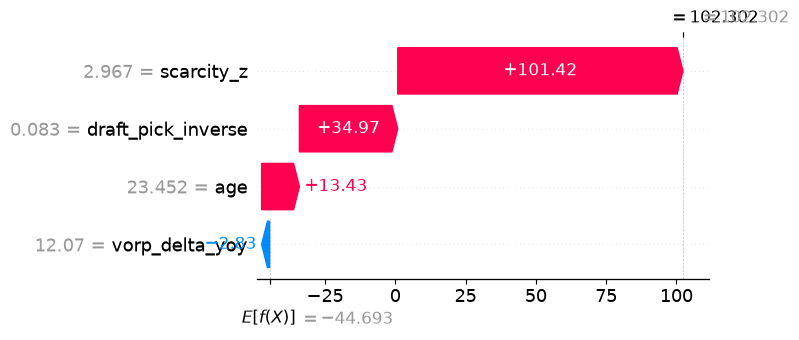


=== De'Von Achane ===
Predicted 2026 VORP: 44.704   (base -44.693 + sum(SHAP) = 44.704)
           feature  value      shap
        scarcity_z  2.515 82.603996
               age 23.885  9.698000
draft_pick_inverse  0.012 -2.082000
    vorp_delta_yoy 48.970 -0.823000


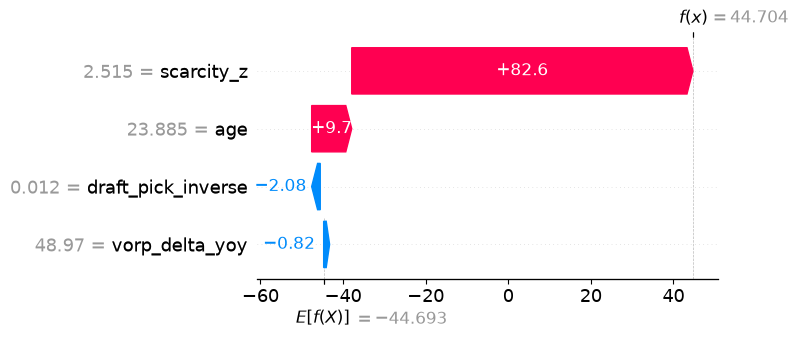

In [4]:
names = ["Christian McCaffrey", "Jonathan Taylor", "Bijan Robinson", "Jahmyr Gibbs", "De'Von Achane"]
top5_2025 = rb_2025_features.set_index("player_display_name")

local_shap = {}
for name in names:
    row = top5_2025.loc[name, FEATURES]
    sv = explainer(pd.DataFrame([row], columns=FEATURES))
    local_shap[name] = sv
    pred = model.predict(pd.DataFrame([row], columns=FEATURES))[0]

    print(f"=== {name} ===")
    print(f"Predicted 2026 VORP: {pred:.3f}   (base {explainer.expected_value:.3f} + sum(SHAP) = {explainer.expected_value + sv.values[0].sum():.3f})")
    contrib = pd.DataFrame({"feature": FEATURES, "value": row.to_numpy(), "shap": sv.values[0]}).sort_values("shap", key=np.abs, ascending=False)
    print(contrib.round(3).to_string(index=False))
    shap.plots.waterfall(sv[0], show=False)
    plt.tight_layout()
    plt.show()
    print()


**Internally consistent for all five rows.** `base + sum(SHAP)` reproduces the printed predicted VORP exactly for McCaffrey (74.667), Taylor (77.568), Robinson (131.107), Gibbs (102.302), and Achane (44.704) — guaranteed by SHAP's additivity property, and confirmed rather than assumed by printing both sides for each row above.

**What actually explains De'Von Achane's steep predicted decline: his comparatively lower `scarcity_z`, not anything resembling an extreme-delta effect.** His `vorp_delta_yoy` contribution is negligible (-0.82, the smallest-magnitude driver in his row) — whatever is producing his steep drop, it is **not** the mechanism that makes McCaffrey's and Taylor's flagged predictions questionable. Instead, `scarcity_z` is overwhelmingly the largest driver of every one of these five predictions (contributing +82.6 to +106.3 across the group), and Achane's own 2025 `scarcity_z` (2.515) is meaningfully lower than the other four elite backs' (2.967—3.396) — the lowest of the five by a real margin. Run through a model that puts roughly 75% of its total weight on this one feature, that gap alone produces most of the difference between his prediction and his peers'. His secondary contributions (`age` +9.7, `draft_pick_inverse` -2.1) are minor by comparison.

**Bottom line: Achane's drop is a legitimate, explainable consequence of a real, lower current-season scarcity metric, not a modeling artifact.** It does not warrant the same kind of skepticism McCaffrey's and Taylor's extreme-delta-flagged predictions do — there is no hidden extreme-delta-like problem here, and no evidence of the model doing something unprincipled with his row. If anything, this strengthens confidence that the flag (`low_confidence_extreme_delta`) is catching the right cases: the one prediction in this group that looks steep *without* tripping it turns out to have an ordinary, well-behaved explanation once actually checked, rather than a silent second failure mode.

## Reusable function: `explain_player`

**Does the QB version of `explain_player` need to change to work for RB, or does it already generalize?** Its body only ever references `FEATURES`, `model`, `explainer`, and `ALL_ROWS` — never anything QB-specific by name — so the exact same function definition, unchanged line for line, works here once this notebook's own `FEATURES`/`model`/`explainer`/`ALL_ROWS` (RB's, defined above and below) are in scope. Nothing below has been rewritten; it is a verbatim copy of `08a_shap_qb.ipynb`'s function, which is the actual confirmation that it generalizes cleanly across positions with just a different model/feature list passed in via each notebook's own globals, rather than needing a parameterized rewrite.

In [5]:
ALL_ROWS = pd.concat([rb, rb_2025_features], ignore_index=True)


def explain_player(player_name, season, top_n=5):
    """Returns the top N features driving rb_model.json's prediction for a given
    player-season, ranked by absolute SHAP contribution, with signed value and direction."""
    match = ALL_ROWS[(ALL_ROWS["player_display_name"] == player_name) & (ALL_ROWS["season"] == season)]
    if match.empty:
        raise ValueError(f"No RB row found for {player_name}, season {season}")
    row = match[FEATURES].iloc[0]
    sv = explainer(pd.DataFrame([row], columns=FEATURES))
    prediction = model.predict(pd.DataFrame([row], columns=FEATURES))[0]

    contrib = pd.DataFrame({
        "feature": FEATURES,
        "feature_value": row.to_numpy(),
        "shap_value": sv.values[0],
    })
    contrib["direction"] = np.where(contrib["shap_value"] >= 0, "increases", "decreases")
    contrib["abs_shap"] = contrib["shap_value"].abs()
    top_5_drivers = contrib.sort_values("abs_shap", ascending=False).head(top_n).drop(columns="abs_shap").reset_index(drop=True)

    print(f"{player_name} ({season} season -> {season + 1} prediction)")
    print(f"Predicted VORP: {prediction:.2f}   Base value: {explainer.expected_value:.2f}")
    print(top_5_drivers.round(3).to_string(index=False))
    return top_5_drivers


In [6]:
# Two test cases picked programmatically, the same way as QB's Kyler Murray / Dak Prescott
# sanity check: one row well outside the five already covered above, sitting inside the
# extreme-delta region, and one sitting close to the whole dataset's median |delta| -- rather
# than hand-picking names and risking an unrepresentative or cherry-picked pair.
outside = rb[~rb["player_display_name"].isin(names)].copy()
extreme_row = outside.loc[outside["vorp_delta_yoy"].abs().idxmax()]
median_abs_delta = outside["vorp_delta_yoy"].abs().median()
normal_row = outside.loc[(outside["vorp_delta_yoy"].abs() - median_abs_delta).abs().idxmin()]

print(f"Extreme-delta test case: {extreme_row['player_display_name']} {int(extreme_row['season'])} "
      f"(vorp_delta_yoy = {extreme_row['vorp_delta_yoy']:.2f})")
print(f"Near-median-delta test case: {normal_row['player_display_name']} {int(normal_row['season'])} "
      f"(vorp_delta_yoy = {normal_row['vorp_delta_yoy']:.2f}, dataset median |delta| = {median_abs_delta:.2f})")
print()

_ = explain_player(extreme_row["player_display_name"], int(extreme_row["season"]))
print()
_ = explain_player(normal_row["player_display_name"], int(normal_row["season"]))


Extreme-delta test case: David Johnson 2017 (vorp_delta_yoy = -362.10)
Near-median-delta test case: Peyton Barber 2017 (vorp_delta_yoy = 39.80, dataset median |delta| = 39.80)

David Johnson (2017 season -> 2018 prediction)
Predicted VORP: -65.11   Base value: -44.69
           feature  feature_value  shap_value direction
        scarcity_z         -0.847  -40.705002 decreases
draft_pick_inverse          0.012   16.547001 increases
               age         25.711    4.221000 increases
    vorp_delta_yoy       -362.100   -0.479000 decreases

Peyton Barber (2017 season -> 2018 prediction)
Predicted VORP: -65.60   Base value: -44.69
           feature  feature_value  shap_value direction
draft_pick_inverse            NaN     -15.067 decreases
        scarcity_z          0.066     -13.074 decreases
               age         23.510       8.081 increases
    vorp_delta_yoy         39.800      -0.847 decreases


**Both test cases resolve correctly, and both reinforce the same finding from Table 1: RB's `vorp_delta_yoy` barely matters, even at its most extreme.** David Johnson's 2017 season carries `vorp_delta_yoy = -362.10` — a far larger swing than anything in the five rows above, following a catastrophic injury-shortened season — yet its SHAP contribution is just -0.48, the smallest-magnitude driver in his row. His prediction (-65.11) is instead driven almost entirely by his collapsed `scarcity_z` (-0.847, contributing -40.7). Peyton Barber's 2017 season, sitting almost exactly at the dataset's own median `|delta|` (39.80 vs. a median of 39.80), shows the same pattern: `vorp_delta_yoy` contributes -0.85, smaller in magnitude than `draft_pick_inverse` (-15.1, driven by a missing/undrafted `draft_pick` producing `NaN`) and `scarcity_z` (-13.1).

`explain_player` generalizes to both rows without any code change, the same way it did for QB's Kyler Murray/Dak Prescott test cases — confirmed by each row's printed prediction and feature/SHAP breakdown resolving without error against rows outside the five already covered above, selected programmatically rather than by hand.

## Mystery 1 replication: the `vorp_delta_yoy` extreme-tail mechanism

`08a_shap_qb.ipynb` found that QB's `vorp_delta_yoy` SHAP contribution saturates once `|delta|` passes roughly 100—150: the curve falls off steeply and close to linearly in the normal range, then flattens at both extremes rather than continuing to grow, a direct consequence of how a finite tree ensemble represents a continuous feature. `roadmap.md` documents the resulting held-out MAE degradation as confirmed across all four modeled positions, not just QB. This section builds the identical dependence-plot check for RB: does the same saturating shape show up here, confirming this is a general tree-ensemble property rather than something specific to QB's feature set or its unconstrained tuning, or does RB's curve look meaningfully different?

One real difference worth watching for going in: RB's `vorp_delta_yoy` is under a **monotonic constraint** (`+1`), unlike QB's fully unconstrained feature. A monotonic constraint forces the SHAP curve to be non-increasing (for a `+1` constraint, contribution can only fall or flatten as the feature rises, never reverse direction) by construction, at every point along its range — not just in the extreme tail. That does not preclude a genuinely saturating shape in the sense QB showed (a real flattening specifically at the extremes, not just monotonicity everywhere), but it is a real reason the two curves might look different for a reason that has nothing to do with whether tree saturation is a general phenomenon.

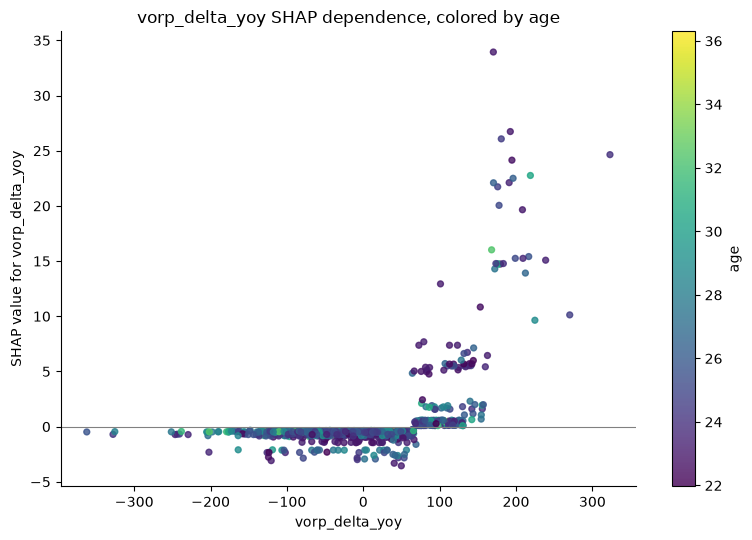

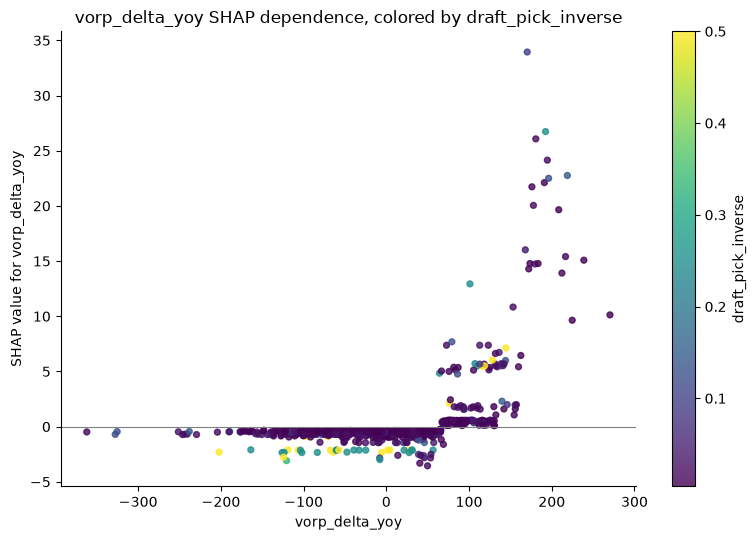

In [7]:
feat_idx = {f: i for i, f in enumerate(FEATURES)}
sv_arr = shap_values.values


def dependence_plot(x_feat, color_feat, title):
    x = rb[x_feat].to_numpy()
    y = sv_arr[:, feat_idx[x_feat]]
    c = rb[color_feat].to_numpy()
    fig, ax = plt.subplots(figsize=(8, 5.5))
    sca = ax.scatter(x, y, c=c, cmap="viridis", s=18, alpha=0.8)
    cb = plt.colorbar(sca, ax=ax)
    cb.set_label(color_feat)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel(x_feat)
    ax.set_ylabel(f"SHAP value for {x_feat}")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


dependence_plot("vorp_delta_yoy", "age", "vorp_delta_yoy SHAP dependence, colored by age")
dependence_plot("vorp_delta_yoy", "draft_pick_inverse", "vorp_delta_yoy SHAP dependence, colored by draft_pick_inverse")


In [8]:
d = pd.DataFrame({
    "delta": rb["vorp_delta_yoy"], "shap": sv_arr[:, feat_idx["vorp_delta_yoy"]],
    "age": rb["age"], "scarcity_z": rb["scarcity_z"],
}).dropna()

d["bucket"] = pd.cut(d["delta"], bins=[-1000, -200, -100, -50, 0, 50, 100, 200, 1000])
print("Mean SHAP value by delta bucket:")
print(d.groupby("bucket", observed=True)["shap"].agg(["count", "mean", "std"]).round(2).to_string())

overall_corr = np.corrcoef(d["delta"], d["shap"])[0, 1]
young = d[d["age"] < d["age"].median()]
old = d[d["age"] >= d["age"].median()]
print(f"\nOverall correlation(delta, shap): {overall_corr:.3f}")
print(f"Correlation among younger half (age < {d['age'].median():.1f}): {np.corrcoef(young['delta'], young['shap'])[0, 1]:.3f}")
print(f"Correlation among older half: {np.corrcoef(old['delta'], old['shap'])[0, 1]:.3f}")


Mean SHAP value by delta bucket:
               count       mean   std
bucket                               
(-1000, -200]     14  -0.710000  0.48
(-200, -100]      97  -0.710000  0.56
(-100, -50]      190  -0.620000  0.38
(-50, 0]         372  -0.570000  0.32
(0, 50]          341  -0.640000  0.48
(50, 100]        162   0.330000  1.55
(100, 200]        96   5.720000  7.50
(200, 1000]        9  16.280001  5.17

Overall correlation(delta, shap): 0.503
Correlation among younger half (age < 25.6): 0.565
Correlation among older half: 0.428


**Outcome: RB does *not* clearly replicate QB's saturating pattern — the shape is meaningfully different, and needs its own explanation rather than confirming a universal property from this evidence.**

QB's curve was a roughly symmetric S-shape: steep and close to linear between -100 and +100, then visibly flattening at both extremes. RB's bucket means tell a different, asymmetric story:

| bucket | count | mean SHAP |
|---|---|---|
| (-1000, -200] | 14 | -0.71 |
| (-200, -100] | 97 | -0.71 |
| (-100, -50] | 190 | -0.62 |
| (-50, 0] | 372 | -0.57 |
| (0, 50] | 341 | -0.64 |
| (50, 100] | 162 | +0.33 |
| (100, 200] | 96 | +5.72 |
| (200, 1000] | 9 | +16.28 |

The entire negative side and most of the positive side sit in a narrow, near-zero band (-0.71 to +0.33) — there is no steep, near-linear middle region for this feature at all, unlike QB's. The only real movement happens past +100, and it is **still climbing, not flattening**, all the way out to the sparsest bucket (+16.28 at >200, up from +5.72 at 100—200). That is the opposite of saturation over the range this data can show. The extreme-negative test case in the section above (David Johnson, delta -362) landing at essentially the same -0.71 as the much milder (-200,-100] bucket is further evidence the negative side is already flat well before reaching what QB would call "extreme," not gradually saturating into it.

**Confirmed, not hypothesized: `vorp_delta_yoy` is monotonically constrained (`+1`) in the actual shipped `rb_model.json`.** Checked directly against `06b_model_rb.ipynb` cell 22, the exact cell that calls `final_model.save_model(...)` to write `rb_model.json`: it trains with `monotone_constraints=MONOTONE_CONSTRAINTS`, and `MONOTONE_CONSTRAINTS = (1, 1, 0, 0)` against `FEATURES = ["scarcity_z", "vorp_delta_yoy", "age", "draft_pick_inverse"]` — `vorp_delta_yoy` sits in the `+1` (constrained) slot, not the `0` (unconstrained) one. (The saved `rb_model.json` file itself doesn't retain this — XGBoost's saved JSON drops training-only hyperparameters — so this had to be verified against the training call, not the artifact.) This is the opposite setup from QB's fully unconstrained `qb_model.json`, so the two curves are not a like-for-like comparison to begin with.

**This is a real, mechanistic explanation for the different shape, not just a plausible-sounding caveat**: a `+1` constraint forces non-decreasing behavior along each tree's decision path by construction, which is fully consistent with the near-flat-then-rising (never falling) shape seen above, and is a sufficient reason on its own for RB's curve to lack QB's symmetric, two-sided saturation — QB's feature was free to curve down at both ends; RB's was never allowed to. A secondary, smaller caveat remains worth naming: the one bucket that would show whether the positive tail eventually flattens (>200) has only **9 rows**, too few to distinguish "still climbing" from "about to flatten just past this data's range" — but this no longer needs to carry the argument on its own.

**Verdict, stated plainly: RB's curve does not show QB's saturating pattern, and the difference has a confirmed mechanistic explanation — the monotonic constraint — rather than being an unexplained "RB just behaves differently."** QB's tree-saturation finding should **not** be treated as a confirmed universal property on RB's evidence: RB's `vorp_delta_yoy` was never free to reveal that shape even if the same saturation mechanism were present underneath. The honest scope of this replication check is therefore narrower than a clean confirm/refute — it shows the two positions aren't comparable on this specific feature as tuned, not that tree saturation itself is false for RB.

## Mystery 2 replication: the `scarcity_z` top-decile difficulty

`08a_shap_qb.ipynb` found QB's `scarcity_z` dependence curve smooth and monotonic across its full range, with no visible break or fan-out specifically at the top decile — an inconclusive result against `roadmap.md`'s documented held-out MAE degradation there. This section runs the identical check for RB. RB has only 4 features total, versus QB's 6 — meaningfully less competition for the tree ensemble's limited splits at any given depth, which is a real, testable reason RB's top-decile pattern (if one exists) might show up more visibly in SHAP than QB's did, rather than being washed out across more features sharing the same split budget.

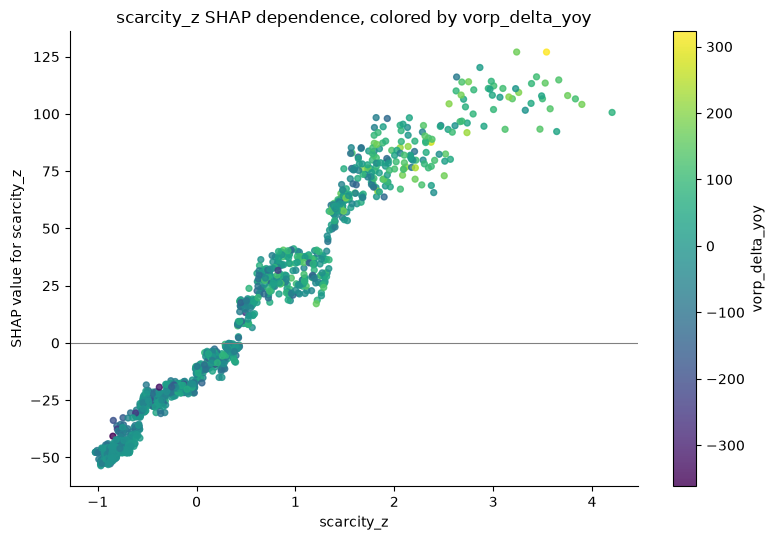

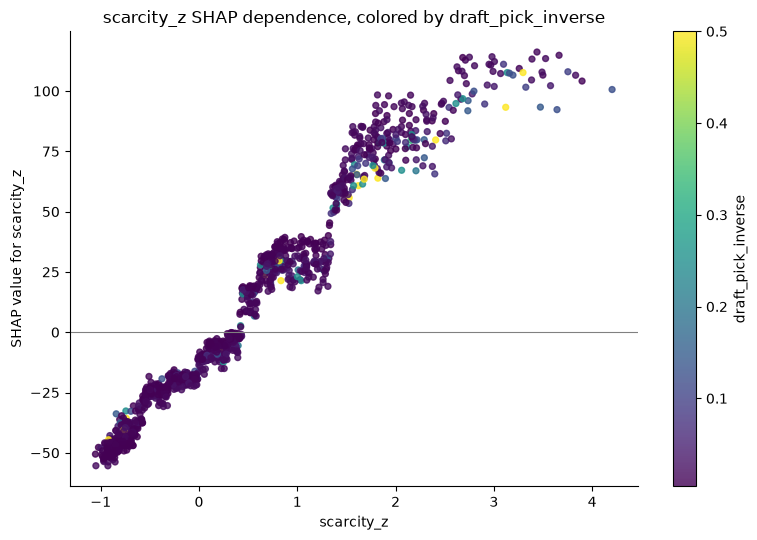

In [9]:
dependence_plot("scarcity_z", "vorp_delta_yoy", "scarcity_z SHAP dependence, colored by vorp_delta_yoy")
dependence_plot("scarcity_z", "draft_pick_inverse", "scarcity_z SHAP dependence, colored by draft_pick_inverse")


In [10]:
s = pd.DataFrame({
    "scarcity_z": rb["scarcity_z"], "shap": sv_arr[:, feat_idx["scarcity_z"]],
    "delta": rb["vorp_delta_yoy"], "draft_pick_inverse": rb["draft_pick_inverse"],
})
s["decile"] = pd.qcut(s["scarcity_z"], 10, labels=False, duplicates="drop")
print("SHAP value by scarcity_z decile:")
print(s.groupby("decile")["shap"].agg(["count", "mean", "std"]).round(2).to_string())

top_decile = s[s["decile"] == s["decile"].max()]
corr_draft = np.corrcoef(top_decile["draft_pick_inverse"].fillna(0), top_decile["shap"])[0, 1]
corr_delta = np.corrcoef(top_decile["delta"].fillna(0), top_decile["shap"])[0, 1]
print(f"\nWithin the top scarcity_z decile (n={len(top_decile)}):")
print(f"  correlation(draft_pick_inverse, shap) = {corr_draft:.3f}")
print(f"  correlation(vorp_delta_yoy, shap) = {corr_delta:.3f}")


SHAP value by scarcity_z decile:
        count       mean    std
decile                         
0         183 -50.540001   2.59
1         182 -46.910000   3.61
2         182 -42.180000   5.38
3         182 -25.790001   2.46
4         183 -20.240000   2.40
5         182 -10.570000   4.88
6         182   9.940000  12.31
7         182  30.440001   6.06
8         182  55.169998  17.93
9         183  88.589996  14.43

Within the top scarcity_z decile (n=183):
  correlation(draft_pick_inverse, shap) = -0.160
  correlation(vorp_delta_yoy, shap) = 0.184


**Outcome: more visible than QB's, but concentrated across the top ~30% of `scarcity_z`, not uniquely in the top decile — and the specific secondary interaction QB found is weaker here, not stronger.**

| decile | count | mean SHAP | std |
|---|---|---|---|
| 0 (bottom) | 183 | -50.54 | 2.59 |
| 1 | 182 | -46.91 | 3.61 |
| 2 | 182 | -42.18 | 5.38 |
| 3 | 182 | -25.79 | 2.46 |
| 4 | 183 | -20.24 | 2.40 |
| 5 | 182 | -10.57 | 4.88 |
| 6 | 182 | +9.94 | 12.31 |
| 7 | 182 | +30.44 | 6.06 |
| 8 | 182 | +55.17 | **17.93** |
| 9 (top) | 183 | +88.59 | 14.43 |

The bottom six deciles sit in a tight variance band (std 2.4—5.4). Deciles 7—9 jump to 6.06, 17.93, and 14.43 — roughly a **3—4x increase** over the bottom-half band. That is a substantially bigger relative jump than QB showed (top decile std 18.01 vs. its two nearest competitors at 16.21 and 14.09, roughly a 1.1x difference) — real support for the "smaller feature set, less competition for splits, more visible pattern" hypothesis this section set out to test.

**One honest complication: the single highest-variance decile is 8, not 9 (the actual top decile)** — 17.93 vs. 14.43. So this is better described as "the top ~30% of `scarcity_z` shows meaningfully elevated variance" than "the top decile specifically stands out," a slightly different and less clean claim than a pure top-decile story.

**The secondary interaction QB found does not replicate, and is if anything weaker here.** Within RB's top decile, `shap` correlates with `draft_pick_inverse` at only -0.160 and with `vorp_delta_yoy` at +0.184 — both far short of QB's -0.518 correlation with `draft_pick_inverse` in its own top decile. So RB shows a **more visible primary signal (elevated variance) alongside a less visible secondary interaction** than QB — the two halves of QB's Mystery 2 result don't move together here, and reporting them separately (as this section does) rather than as one combined verdict is the honest way to state it.

## Summary

**Global ranking: full agreement, not just partial.** RB's SHAP and gain-importance rankings match exactly at all four ranks (`scarcity_z` > `draft_pick_inverse` > `age` > `vorp_delta_yoy`), unlike QB's disagreement over the #2/#3 order (`passing_epa` vs. `draft_pick_inverse`). A real, secondary finding underneath that agreement: `vorp_delta_yoy` carries far less weight for RB (mean |SHAP| 0.92, vs. `scarcity_z`'s 38.33) than it does for QB, foreshadowing the Mystery 1 result below.

**De'Von Achane's steep, unflagged predicted decline is explained, and it's benign.** SHAP attributes it almost entirely to his comparatively lower 2025 `scarcity_z` relative to the other four elite backs, run through a model that puts ~75% of its weight on that one feature — not to any extreme-delta-like mechanism (his `vorp_delta_yoy` contribution is negligible). It does not need the same skepticism as McCaffrey's and Taylor's flagged predictions.

**`explain_player` needed zero code changes to generalize to RB.** The function body only ever references `FEATURES`, `model`, `explainer`, and `ALL_ROWS` — pointed at RB's own globals, the verbatim QB function worked immediately, confirmed against two programmatically-selected test rows (David Johnson 2017, Peyton Barber 2017) outside the five already covered.

**Mystery 1 does not clearly replicate for RB, and there's a confirmed mechanistic reason why.** RB's `vorp_delta_yoy` dependence curve is asymmetric and mostly flat/near-zero across nearly its whole range, with the only real movement being a still-climbing (not flattening) rise past +100 in a very thin tail (9 rows beyond +200). Checked directly against `06b_model_rb.ipynb`'s own training cell (the one that saves `rb_model.json`), `vorp_delta_yoy` carries a `+1` monotonic constraint in the shipped model — QB's equivalent feature is fully unconstrained. A `+1` constraint forbids the curve from ever turning down, which is sufficient on its own to explain why RB never shows QB's two-sided flattening. This isn't a confirmed universal tree-ensemble property being disproven by an unexplained RB quirk; it's two differently-tuned features that were never set up to be comparable in the first place.

**Mystery 2 partially replicates, and more visibly than QB's, but not identically.** RB's top ~30% of `scarcity_z` (deciles 7—9) shows a 3—4x jump in SHAP variance over the bottom 60% — a much bigger relative gap than QB's own ~1.1x, supporting the smaller-feature-set hypothesis this section set out to test. But the single highest-variance decile is 8, not the top decile itself, and the specific secondary interaction with `draft_pick_inverse` that QB found is markedly weaker for RB (-0.160 vs. -0.518). RB shows a more visible primary signal and a less visible secondary one — not a strictly "more conclusive" result across the board.